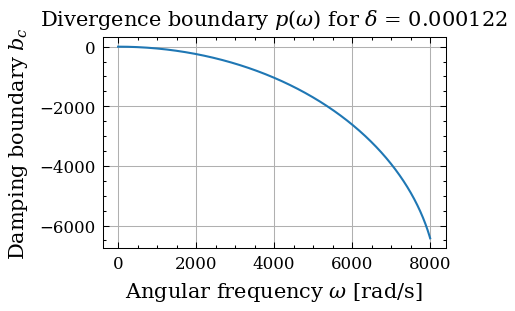

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from brf_lightning.utils.plot_defaults import new_figure, init_plot_style

init_plot_style()

delta = 0.0001220703125  # 1/ 8192 hz -> f_s
omegas = np.linspace(0, 8000, 1000)
# avoiding negative under root
mask = delta * omegas <= 1
omegas = omegas[mask]
p = (-1 + np.sqrt(1 - (delta * omegas)**2)) / delta

fig, ax = new_figure(fraction=0.5)

ax.plot(omegas, p)
ax.set_xlabel(r"Angular frequency $\omega$ [$\mathrm{rad}/\mathrm{s}$]")
ax.set_ylabel("Damping boundary $b_c$")
ax.set_title(r"Divergence boundary $p(\omega)$ for $\delta$ = {:.6f}".format(delta))
ax.grid(True)

plt.show()


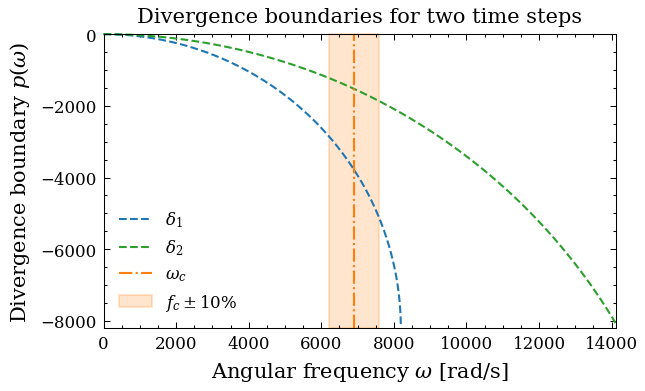

[PGF Export] Saved figure to 'notebooks/thesis/plots/divergence_boundary/carrier_divergence_example.pgf'.


In [31]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from brf_lightning.utils.plot_defaults import export_figure_to_pgf

# Apply plotting style
init_plot_style()

# Define two time steps
delta1 = 1/8192
delta2 = 1/16384

# Create omega vector beyond both limits:
omega_max = 14125  # extend beyond 1/delta1 ~ 8192
omega = np.linspace(0, omega_max, 10000)

# Compute masked p(ω):
def calc_p(delta):
    x = delta * omega
    valid = np.logical_or(x < 1, np.isclose(x, 1))
    p = np.empty_like(omega)
    p[valid] = (-1 + np.sqrt(1 - x[valid]**2)) / delta
    p[~valid] = np.nan
    return p

p1 = calc_p(delta1)
p2 = calc_p(delta2)

# Carrier frequency
omega_c = 2 * np.pi * 1100

fig, ax = new_figure(fraction=0.75)
colors = mpl.rcParams['axes.prop_cycle'].by_key()['color']
c1, c_carr, c2  = colors[:3]

# Plot only physically valid parts
valid1 = omega <= 1/delta1
valid2 = omega <= 1/delta2

ax.plot(omega[valid1], p1[valid1],
        color=c1, linestyle='--', clip_on=False, label=r'$\delta_1$')
ax.plot(omega[valid2], p2[valid2],
        color=c2, linestyle='--', clip_on=False, label=r'$\delta_2$')

# Vertical carrier line
ax.axvline(omega_c, color=c_carr, linestyle='-.', clip_on=False,
           label=r'$\omega_c$')

# Plot limits before shading
ax.set_xlim(0, omega_max)
ax.set_ylim(-8192, 0)
ymin, ymax = ax.get_ylim()

# Carrier ±10% band
ax.fill_betweenx([ymin, ymax],
                 omega_c*0.9, omega_c*1.1,
                 color=c_carr, alpha=0.2, clip_on=False,
                 label=r'$f_c \pm10\%$')

# Labels and legend
ax.set_xlabel(r'Angular frequency $\omega$ [rad/s]')
ax.set_ylabel(r'Divergence boundary $p(\omega)$')
ax.set_title('Divergence boundaries for two time steps')
ax.legend(loc='lower left', frameon=False)

plt.tight_layout()
plt.show()

export_figure_to_pgf(fig, "notebooks/thesis/plots/divergence_boundary/carrier_divergence_example.pgf")

## Frault Frequencies

/tmp/ipykernel_113937/1141791969.py:10: RuntimeWarning: invalid value encountered in sqrt
  p = (-1 + np.sqrt(1 - (delta * omega)**2)) / delta


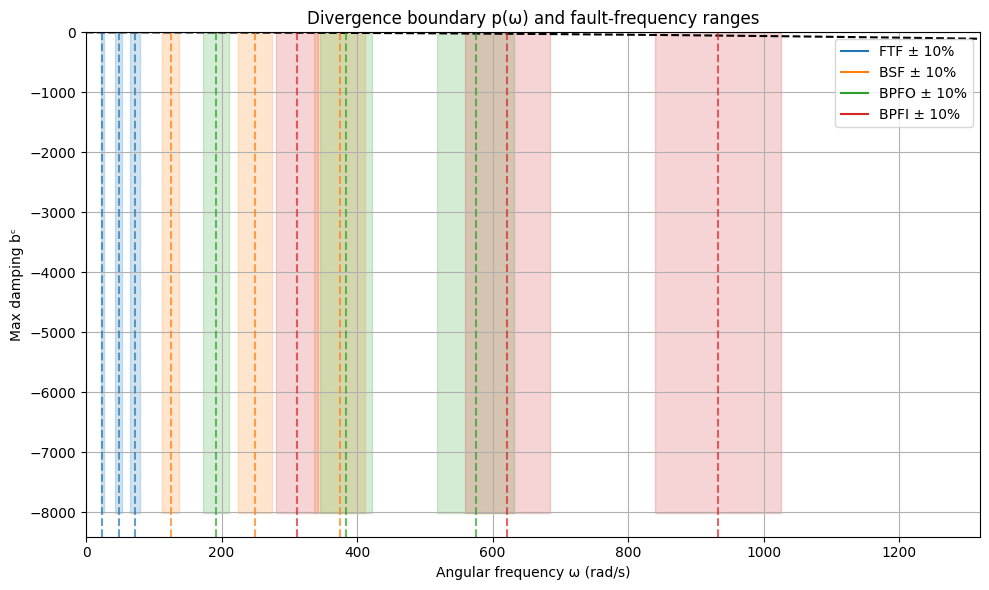

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# sampling timestep (dt = 1 / 8192)
delta = 0.0001220703125

# angular frequency grid up to Nyquist (π/delta)
omega = np.linspace(0, np.pi / delta, 10000)
valid = delta * omega <= 1
p = (-1 + np.sqrt(1 - (delta * omega)**2)) / delta
p = np.where(valid, p, np.nan)

# fault frequency table (Hz)
faults = {
    'FTF':  [3.81,  7.63, 11.44],
    'BSF':  [19.86, 39.73, 59.59],
    'BPFO': [30.50, 60.99, 91.50],
    'BPFI': [49.50, 99.00, 148.50]
}

plt.figure(figsize=(10, 6))

# divergence boundary curve
plt.plot(omega, p, color='black', linestyle='--')

# plot fault-frequency markers and bands
colors = {'FTF':'C0', 'BSF':'C1', 'BPFO':'C2', 'BPFI':'C3'}
for fault, freqs in faults.items():
    for f in freqs:
        omega_f = 2 * np.pi * f
        plt.axvline(omega_f, color=colors[fault], linestyle='--', alpha=0.7)
        plt.fill_betweenx(
            [np.nanmin(p), 0],
            omega_f * 0.9,
            omega_f * 1.1,
            color=colors[fault],
            alpha=0.2
        )
    plt.plot([], [], color=colors[fault], label=f'{fault} ± 10%')

plt.xlabel('Angular frequency ω (rad/s)')
plt.ylabel('Max damping bᶜ')
plt.title('Divergence boundary p(ω) and fault-frequency ranges')
plt.ylim(np.nanmin(p)*1.05, 0.1)
plt.xlim(0, 2 * np.pi * 150 * 1.4)
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
from lightning.pytorch.callbacks import 